# Multilevel missingess

Heleen Brüggen

In [ ]:
#############
# Libraries #
#############
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Loading required package: Matrix

Attaching package: 'Matrix'

The following objects are masked from 'package:tidyr':

    expand, pack, unpack

*** This is beta software. Please report any bugs!
*** See the NEWS file for recent changes.


Attaching package: 'mice'

The following object is masked from 'package:stats':

    filter

The following objects are masked from 'package:base':

    cbind, rbind


Attaching package: 'lmerTest'

The following object is masked from 'package:lme4':

    lmer

The following object is masked from 'package:stats':

    step


Attaching package: 'magrittr'

The following object is masked from 'package:purrr':

    set_names

The following object is masked from 'package:tidyr':

    extract

Loading required package: future


Attaching package: 'ggmice'

The following objects are masked from 'package:mice':

    bwplot, densityplot, stripplot, xyplot


Attaching package: 'nlme'

The following object is masked from 'package:lme4':

    lmList

The following object is masked from 'package:dplyr':

    collapse

## Creating missing data in a univariate way

### Adding code from Gerko for univariate missing data

The following code is a function to ampute data according the univariate missingness mechanismsL MAR, MCAR or MNAR. The function has the following arguments:

-   `data`: the data in matrix or data-frame format
-   `mis.var`: the column specifier (number) for the variable to be amputed.
-   `cov.var`:the column specifier (number) for the covariate the MAR missingness is based on
-   `prop.mis`: proportion of missingness. Options are `c(.25, .5)`.
-   `m.mech`: The missingness mechanism. Options are `c("MARleft", "MARright", "MARmid","MARtail", "MCAR")`.

The output is:

-   `data.rm`: the data with missing values
-   `p.MAR`: the probability of missingness
-   `mis.info`: a data frame with the missingness mechanism and the proportion of missing data.

In [ ]:
ampute.data <- function(data, mis.var, cov.var, prop.mis, m.mech = "MARleft") {
    data.rm <- data # assigning data to new object
    n <- nrow(data.rm) # amount of rows in data
    inv.log <- function(x) { # inverse logit function
        exp(x) / (1 + exp(x))
    }
    m.cov <- mean(data.rm[, cov.var]) # mean of covariate variable

    if (prop.mis == .25) { # if prop = 25% ...
        ML <- (mean(data[, cov.var]) - data[, cov.var]) / sd(data[, cov.var]) - 1.3 # ... then MARleft is calculated as ...
        MR <- (-mean(data[, cov.var]) + data[, cov.var]) / sd(data[, cov.var]) - 1.3 # ... MARright is calculated as ...
        MM <- (.75 - abs((data[, cov.var] - mean(data[, cov.var])) / sd(data[, cov.var]))) - 1.15 # ... MARmid is calculated as ...
        MT <- (-.75 + abs((data[, cov.var] - mean(data[, cov.var])) / sd(data[, cov.var]))) - 1.225 # ... MARtail is calculated as ...
    }
    if (prop.mis == .5) { # if prop = 50% ...
        ML <- (mean(data[, cov.var]) - data[, cov.var]) / sd(data[, cov.var]) # ... then MARleft is calculated as ...
        MR <- (-mean(data[, cov.var]) + data[, cov.var]) / sd(data[, cov.var]) # ... MARright is calculated as ...
        MM <- (.75 - abs((data[, cov.var] - mean(data[, cov.var])) / sd(data[, cov.var]))) # ... MARmid is calculated as ...
        MT <- (-.75 + abs((data[, cov.var] - mean(data[, cov.var])) / sd(data[, cov.var]))) # ... MARtail is calculated as ...
    }

    if (m.mech == "MARleft") { # if missingness mechanism is MARleft ...
        p.MAR <- inv.log(ML) # ... then take inverse logit of ML ...
        data.rm[1 == rbinom(n, 1, p.MAR), mis.var] <- NA # ... and assign NA to the missing variable with a probability of p.MAR
    }

    if (m.mech == "MARright") {
        p.MAR <- inv.log(MR)
        data.rm[1 == rbinom(n, 1, p.MAR), mis.var] <- NA
    }

    if (m.mech == "MARmid") {
        p.MAR <- inv.log(MM)
        data.rm[1 == rbinom(n, 1, p.MAR), mis.var] <- NA
    }

    if (m.mech == "MARtail") {
        p.MAR <- inv.log(MT)
        data.rm[1 == rbinom(n, 1, p.MAR), mis.var] <- NA
    }

    if (m.mech == "MCAR") {
        p.MAR <- rep(prop.mis, nrow(data.rm))
        data.rm[0 == rbinom(n, 1, 1 - prop.mis), mis.var] <- NA
    }

    # Prepare data for return
    true.mis <- mean(is.na(data.rm[, mis.var])) # calculate proportion of missing data
    mis.info <- data.frame(Mechanism = m.mech, Proportion = true.mis) # create data frame with missingness mechanism and proportion of missing data
    output <- list(data.rm, p.MAR, mis.info) # create list with data, p.MAR and mis.info
    names(output) <- c("data", "p.mis", "info") # assign names to list elements
    return(output)
}

### Loading data

In [ ]:
data <- list()
for (i in seq_len(nrow(combinations))) {
    data[[i]] <- read_rds(paste(path, "data/complete/simdata_", names[i], ".rds", sep = ""))[1:100]
}

### Creating missing data

In [ ]:
cor <- map(seq_len(nrow(combinations)), function(i) {
    cor_dat <- lapply(data[[i]], function(x) cor(x[, c("y", "x1", "x2", "x3", "x4", "x5", "x6", "x7", "z1", "z2")])) %>%
        Reduce("+", .) / length(data[[i]])
})

## 30_15_mar

``` r
datatable(
    cor[[1]],
    caption = paste("Correlation of", names[1]),
    options = list(pageLength = 10)
) %>%
    formatRound(columns = 1:10, digits = 3)
```

<div class="datatables html-widget html-fill-item" id="htmlwidget-9eceb20dc2a931752ae4" style="width:100%;height:auto;"></div>
<script type="application/json" data-for="htmlwidget-9eceb20dc2a931752ae4">{"x":{"filter":"none","vertical":false,"caption":"<caption>Correlation of ngroup_30_groupsize_15_icc_0.5_mar_mcar_mar_miss_50_g_0.5<\/caption>","data":[["y","x1","x2","x3","x4","x5","x6","x7","z1","z2"],[1,0.2846926791182941,0.3045171253144323,0.2701491705937394,0.3050917903585442,0.2726812490691131,0.2630570918136425,0.337725075409274,0.05952654415946745,0.07810787047562621],[0.2846926791182941,1,0.2995995689025674,0.3006601926949221,0.2634113380739928,0.2958096989975895,0.3038399513276384,0.304672255078903,0.001033024422310125,0.00479660677738312],[0.3045171253144323,0.2995995689025674,1,0.3021753442582742,0.3008789384571587,0.3025405360054256,0.3057240835885203,0.3001168478103689,-0.003373084844312335,-0.004233259871854583],[0.2701491705937394,0.3006601926949221,0.3021753442582742,1,0.2938386348967147,0.3041261694528354,0.3017822328350744,0.2989978780059353,0.004301418022766118,-0.006745063195647356],[0.3050917903585442,0.2634113380739928,0.3008789384571587,0.2938386348967147,1,0.2971247718376246,0.2987730917756918,0.296961416077605,-3.903812850392483e-05,-0.003037575792499761],[0.2726812490691131,0.2958096989975895,0.3025405360054256,0.3041261694528354,0.2971247718376246,1,0.3071184562404073,0.2999221255505806,-0.006294106245015354,-0.002887339063961476],[0.2630570918136425,0.3038399513276384,0.3057240835885203,0.3017822328350744,0.2987730917756918,0.3071184562404073,1,0.3040709583910866,-0.004243466739389553,-0.0008670237238038946],[0.337725075409274,0.304672255078903,0.3001168478103689,0.2989978780059353,0.296961416077605,0.2999221255505806,0.3040709583910866,1,0.002502706920087391,0.003331738477308296],[0.05952654415946745,0.001033024422310125,-0.003373084844312335,0.004301418022766118,-3.903812850392483e-05,-0.006294106245015354,-0.004243466739389553,0.002502706920087391,1,0.309934641142753],[0.07810787047562621,0.00479660677738312,-0.004233259871854583,-0.006745063195647356,-0.003037575792499761,-0.002887339063961476,-0.0008670237238038946,0.003331738477308296,0.309934641142753,1]],"container":"<table class=\"display\">\n  <thead>\n    <tr>\n      <th> <\/th>\n      <th>y<\/th>\n      <th>x1<\/th>\n      <th>x2<\/th>\n      <th>x3<\/th>\n      <th>x4<\/th>\n      <th>x5<\/th>\n      <th>x6<\/th>\n      <th>x7<\/th>\n      <th>z1<\/th>\n      <th>z2<\/th>\n    <\/tr>\n  <\/thead>\n<\/table>","options":{"pageLength":10,"columnDefs":[{"targets":1,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":2,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":3,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":4,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":5,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":6,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":7,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":8,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":9,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":10,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"className":"dt-right","targets":[1,2,3,4,5,6,7,8,9,10]},{"orderable":false,"targets":0},{"name":" ","targets":0},{"name":"y","targets":1},{"name":"x1","targets":2},{"name":"x2","targets":3},{"name":"x3","targets":4},{"name":"x4","targets":5},{"name":"x5","targets":6},{"name":"x6","targets":7},{"name":"x7","targets":8},{"name":"z1","targets":9},{"name":"z2","targets":10}],"order":[],"autoWidth":false,"orderClasses":false}},"evals":["options.columnDefs.0.render","options.columnDefs.1.render","options.columnDefs.2.render","options.columnDefs.3.render","options.columnDefs.4.render","options.columnDefs.5.render","options.columnDefs.6.render","options.columnDefs.7.render","options.columnDefs.8.render","options.columnDefs.9.render"],"jsHooks":[]}</script>

## 50_15_mar

``` r
datatable(
    cor[[2]],
    caption = paste("Correlation of", names[2]),
    options = list(pageLength = 10)
) %>%
    formatRound(columns = 1:10, digits = 3)
```

<div class="datatables html-widget html-fill-item" id="htmlwidget-f30d7598595affc4f25a" style="width:100%;height:auto;"></div>
<script type="application/json" data-for="htmlwidget-f30d7598595affc4f25a">{"x":{"filter":"none","vertical":false,"caption":"<caption>Correlation of ngroup_50_groupsize_15_icc_0.5_mar_mcar_mar_miss_50_g_0.5<\/caption>","data":[["y","x1","x2","x3","x4","x5","x6","x7","z1","z2"],[1,0.2732165654571246,0.28944089950723,0.2698533961295365,0.3077064372427663,0.2667665343042979,0.2543364945723476,0.3371634944829789,0.06568154545433494,0.06993131906217456],[0.2732165654571246,1,0.2949751689910416,0.3000465973505422,0.266831095949621,0.3007929838649955,0.2970546559749247,0.2994548100748763,-0.003339969455862524,-0.005060010582144658],[0.28944089950723,0.2949751689910416,1,0.3033137984132454,0.3023933494357289,0.2973311401383653,0.2972131457534825,0.2978639200019806,-0.003295075527072987,-0.001265775737164189],[0.2698533961295365,0.3000465973505422,0.3033137984132454,1,0.3006161085927965,0.3009283198327143,0.2960992760492762,0.3010586051161029,-0.001552512311745717,-0.005545100062023855],[0.3077064372427663,0.266831095949621,0.3023933494357289,0.3006161085927965,1,0.3001729782086819,0.2985792489037981,0.2992309561451535,-0.003699482082413988,-0.001997784608642984],[0.2667665343042979,0.3007929838649955,0.2973311401383653,0.3009283198327143,0.3001729782086819,1,0.299242635491255,0.2994404911318029,-0.003440759331171695,-0.001402930711863553],[0.2543364945723476,0.2970546559749247,0.2972131457534825,0.2960992760492762,0.2985792489037981,0.299242635491255,1,0.2977117897298056,-0.009678579468825799,-0.001228747470976193],[0.3371634944829789,0.2994548100748763,0.2978639200019806,0.3010586051161029,0.2992309561451535,0.2994404911318029,0.2977117897298056,1,-0.0003242720234984543,0.00102345705475605],[0.06568154545433494,-0.003339969455862524,-0.003295075527072987,-0.001552512311745717,-0.003699482082413988,-0.003440759331171695,-0.009678579468825799,-0.0003242720234984543,1,0.3025085063822959],[0.06993131906217456,-0.005060010582144658,-0.001265775737164189,-0.005545100062023855,-0.001997784608642984,-0.001402930711863553,-0.001228747470976193,0.00102345705475605,0.3025085063822959,1]],"container":"<table class=\"display\">\n  <thead>\n    <tr>\n      <th> <\/th>\n      <th>y<\/th>\n      <th>x1<\/th>\n      <th>x2<\/th>\n      <th>x3<\/th>\n      <th>x4<\/th>\n      <th>x5<\/th>\n      <th>x6<\/th>\n      <th>x7<\/th>\n      <th>z1<\/th>\n      <th>z2<\/th>\n    <\/tr>\n  <\/thead>\n<\/table>","options":{"pageLength":10,"columnDefs":[{"targets":1,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":2,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":3,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":4,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":5,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":6,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":7,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":8,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":9,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":10,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"className":"dt-right","targets":[1,2,3,4,5,6,7,8,9,10]},{"orderable":false,"targets":0},{"name":" ","targets":0},{"name":"y","targets":1},{"name":"x1","targets":2},{"name":"x2","targets":3},{"name":"x3","targets":4},{"name":"x4","targets":5},{"name":"x5","targets":6},{"name":"x6","targets":7},{"name":"x7","targets":8},{"name":"z1","targets":9},{"name":"z2","targets":10}],"order":[],"autoWidth":false,"orderClasses":false}},"evals":["options.columnDefs.0.render","options.columnDefs.1.render","options.columnDefs.2.render","options.columnDefs.3.render","options.columnDefs.4.render","options.columnDefs.5.render","options.columnDefs.6.render","options.columnDefs.7.render","options.columnDefs.8.render","options.columnDefs.9.render"],"jsHooks":[]}</script>

## 30_50_mar

``` r
datatable(
    cor[[3]],
    caption = paste("Correlation of", names[3]),
    options = list(pageLength = 10)
) %>%
    formatRound(columns = 1:10, digits = 3)
```

<div class="datatables html-widget html-fill-item" id="htmlwidget-b85bf888dc62471906a9" style="width:100%;height:auto;"></div>
<script type="application/json" data-for="htmlwidget-b85bf888dc62471906a9">{"x":{"filter":"none","vertical":false,"caption":"<caption>Correlation of ngroup_30_groupsize_50_icc_0.5_mar_mcar_mar_miss_50_g_0.5<\/caption>","data":[["y","x1","x2","x3","x4","x5","x6","x7","z1","z2"],[1,0.2720576816137717,0.2903386507363221,0.2601746231556673,0.2992738415690855,0.265409941499233,0.2515389492629321,0.3301102389287226,0.06295583589993456,0.06588117916578294],[0.2720576816137717,1,0.3024236579250209,0.303799214422647,0.2669642975447568,0.3051618952316035,0.3045362586762554,0.3014239033352262,0.002503393918391114,-0.00462383025141403],[0.2903386507363221,0.3024236579250209,1,0.3039653068419778,0.3047683288928941,0.3042476798724227,0.3040698635273311,0.2998219657718153,5.241061026980611e-05,-0.001648967014955632],[0.2601746231556673,0.303799214422647,0.3039653068419778,1,0.3006102233140831,0.298661941825979,0.2987457233546146,0.3014701422699153,0.002859253593854322,-0.0005176390656688368],[0.2992738415690855,0.2669642975447568,0.3047683288928941,0.3006102233140831,1,0.2990422576747377,0.3009815601590267,0.299815821437385,0.001596438713064928,-0.004324756695162201],[0.265409941499233,0.3051618952316035,0.3042476798724227,0.298661941825979,0.2990422576747377,1,0.3015943268401002,0.3000655807419391,-0.003646236915334824,-0.004642837888786526],[0.2515389492629321,0.3045362586762554,0.3040698635273311,0.2987457233546146,0.3009815601590267,0.3015943268401002,1,0.3028538572091783,0.001467425122550126,3.343912136747687e-05],[0.3301102389287226,0.3014239033352262,0.2998219657718153,0.3014701422699153,0.299815821437385,0.3000655807419391,0.3028538572091783,1,-0.001435439826918068,-0.003398809660241825],[0.06295583589993456,0.002503393918391114,5.241061026980611e-05,0.002859253593854322,0.001596438713064928,-0.003646236915334824,0.001467425122550126,-0.001435439826918068,1,0.2841030393399768],[0.06588117916578294,-0.00462383025141403,-0.001648967014955632,-0.0005176390656688368,-0.004324756695162201,-0.004642837888786526,3.343912136747687e-05,-0.003398809660241825,0.2841030393399768,1]],"container":"<table class=\"display\">\n  <thead>\n    <tr>\n      <th> <\/th>\n      <th>y<\/th>\n      <th>x1<\/th>\n      <th>x2<\/th>\n      <th>x3<\/th>\n      <th>x4<\/th>\n      <th>x5<\/th>\n      <th>x6<\/th>\n      <th>x7<\/th>\n      <th>z1<\/th>\n      <th>z2<\/th>\n    <\/tr>\n  <\/thead>\n<\/table>","options":{"pageLength":10,"columnDefs":[{"targets":1,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":2,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":3,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":4,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":5,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":6,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":7,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":8,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":9,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":10,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"className":"dt-right","targets":[1,2,3,4,5,6,7,8,9,10]},{"orderable":false,"targets":0},{"name":" ","targets":0},{"name":"y","targets":1},{"name":"x1","targets":2},{"name":"x2","targets":3},{"name":"x3","targets":4},{"name":"x4","targets":5},{"name":"x5","targets":6},{"name":"x6","targets":7},{"name":"x7","targets":8},{"name":"z1","targets":9},{"name":"z2","targets":10}],"order":[],"autoWidth":false,"orderClasses":false}},"evals":["options.columnDefs.0.render","options.columnDefs.1.render","options.columnDefs.2.render","options.columnDefs.3.render","options.columnDefs.4.render","options.columnDefs.5.render","options.columnDefs.6.render","options.columnDefs.7.render","options.columnDefs.8.render","options.columnDefs.9.render"],"jsHooks":[]}</script>

## 50_50_mar

``` r
datatable(
    cor[[4]],
    caption = paste("Correlation of", names[4]),
    options = list(pageLength = 10)
) %>%
    formatRound(columns = 1:10, digits = 3)
```

<div class="datatables html-widget html-fill-item" id="htmlwidget-88fdd2a34d502a66744b" style="width:100%;height:auto;"></div>
<script type="application/json" data-for="htmlwidget-88fdd2a34d502a66744b">{"x":{"filter":"none","vertical":false,"caption":"<caption>Correlation of ngroup_50_groupsize_50_icc_0.5_mar_mcar_mar_miss_50_g_0.5<\/caption>","data":[["y","x1","x2","x3","x4","x5","x6","x7","z1","z2"],[1,0.2779375032330428,0.292676851651624,0.2690382307791858,0.3022547839313585,0.2689962445275802,0.2593837805813927,0.3347158299630849,0.06258165981261599,0.07779955844424165],[0.2779375032330428,1,0.298992430566523,0.3011413435762028,0.265109618985751,0.299316565767189,0.2998263019663728,0.2998766219644514,0.002103572157830825,0.00205355510922839],[0.292676851651624,0.298992430566523,1,0.3007056614628973,0.2987861909154678,0.2997003469880187,0.3009980970947754,0.298428064660103,7.02506458954553e-05,0.001048776898350752],[0.2690382307791858,0.3011413435762028,0.3007056614628973,1,0.3005986012335918,0.3027319700025644,0.3027626929943045,0.3035934660090777,0.002811921831739468,0.003755884599915144],[0.3022547839313585,0.265109618985751,0.2987861909154678,0.3005986012335918,1,0.3034742312982893,0.3009221395972773,0.3032289051993629,0.003275171760411828,-0.0002919805320304969],[0.2689962445275802,0.299316565767189,0.2997003469880187,0.3027319700025644,0.3034742312982893,1,0.3008971768246673,0.3020495549983728,0.0004007295341588062,0.001072461712144908],[0.2593837805813927,0.2998263019663728,0.3009980970947754,0.3027626929943045,0.3009221395972773,0.3008971768246673,1,0.3012855398517498,0.003838180480037152,0.002090442848364783],[0.3347158299630849,0.2998766219644514,0.298428064660103,0.3035934660090777,0.3032289051993629,0.3020495549983728,0.3012855398517498,1,0.0001314182498349572,0.002640071014238291],[0.06258165981261599,0.002103572157830825,7.02506458954553e-05,0.002811921831739468,0.003275171760411828,0.0004007295341588062,0.003838180480037152,0.0001314182498349572,1,0.2875585241180918],[0.07779955844424165,0.00205355510922839,0.001048776898350752,0.003755884599915144,-0.0002919805320304969,0.001072461712144908,0.002090442848364783,0.002640071014238291,0.2875585241180918,1]],"container":"<table class=\"display\">\n  <thead>\n    <tr>\n      <th> <\/th>\n      <th>y<\/th>\n      <th>x1<\/th>\n      <th>x2<\/th>\n      <th>x3<\/th>\n      <th>x4<\/th>\n      <th>x5<\/th>\n      <th>x6<\/th>\n      <th>x7<\/th>\n      <th>z1<\/th>\n      <th>z2<\/th>\n    <\/tr>\n  <\/thead>\n<\/table>","options":{"pageLength":10,"columnDefs":[{"targets":1,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":2,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":3,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":4,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":5,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":6,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":7,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":8,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":9,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":10,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"className":"dt-right","targets":[1,2,3,4,5,6,7,8,9,10]},{"orderable":false,"targets":0},{"name":" ","targets":0},{"name":"y","targets":1},{"name":"x1","targets":2},{"name":"x2","targets":3},{"name":"x3","targets":4},{"name":"x4","targets":5},{"name":"x5","targets":6},{"name":"x6","targets":7},{"name":"x7","targets":8},{"name":"z1","targets":9},{"name":"z2","targets":10}],"order":[],"autoWidth":false,"orderClasses":false}},"evals":["options.columnDefs.0.render","options.columnDefs.1.render","options.columnDefs.2.render","options.columnDefs.3.render","options.columnDefs.4.render","options.columnDefs.5.render","options.columnDefs.6.render","options.columnDefs.7.render","options.columnDefs.8.render","options.columnDefs.9.render"],"jsHooks":[]}</script>

## 30_15_mcar

``` r
datatable(
    cor[[5]],
    caption = paste("Correlation of", names[5]),
    options = list(pageLength = 10)
) %>%
    formatRound(columns = 1:10, digits = 3)
```

<div class="datatables html-widget html-fill-item" id="htmlwidget-8e1fe96c0688a849169a" style="width:100%;height:auto;"></div>
<script type="application/json" data-for="htmlwidget-8e1fe96c0688a849169a">{"x":{"filter":"none","vertical":false,"caption":"<caption>Correlation of ngroup_30_groupsize_15_icc_0.5_mar_mcar_mcar_miss_50_g_0.5<\/caption>","data":[["y","x1","x2","x3","x4","x5","x6","x7","z1","z2"],[1,0.2753530717016173,0.299795308054678,0.2661279850156877,0.3038004352309053,0.272116415703739,0.2534045964538326,0.3411307030253114,0.05084992561761191,0.05923080798462508],[0.2753530717016173,1,0.3092723541154326,0.2980334072748608,0.2680046000904805,0.2956685226976937,0.2926038216039393,0.3000835881439503,0.0005134236364646323,-0.003970996669608465],[0.299795308054678,0.3092723541154326,1,0.2986253660112043,0.3082703562127837,0.3061295774671758,0.2990673194999927,0.295343654867921,0.00433303858161739,0.003360587684752727],[0.2661279850156877,0.2980334072748608,0.2986253660112043,1,0.3029492014606693,0.3020623124305271,0.2982217952385656,0.2922590631386514,0.006206115996708441,-0.00209263385041541],[0.3038004352309053,0.2680046000904805,0.3082703562127837,0.3029492014606693,1,0.3044311556253003,0.2978105407674228,0.2967066349313718,-0.002850630678044972,-0.003497833185084267],[0.272116415703739,0.2956685226976937,0.3061295774671758,0.3020623124305271,0.3044311556253003,1,0.2978037467240746,0.2986452284631077,0.001392302672877663,0.003446380327840057],[0.2534045964538326,0.2926038216039393,0.2990673194999927,0.2982217952385656,0.2978105407674228,0.2978037467240746,1,0.2936307088050402,0.001483820008850649,0.001263454154872701],[0.3411307030253114,0.3000835881439503,0.295343654867921,0.2922590631386514,0.2967066349313718,0.2986452284631077,0.2936307088050402,1,0.003028163348203803,0.001049128417561562],[0.05084992561761191,0.0005134236364646323,0.00433303858161739,0.006206115996708441,-0.002850630678044972,0.001392302672877663,0.001483820008850649,0.003028163348203803,1,0.3024397301163098],[0.05923080798462508,-0.003970996669608465,0.003360587684752727,-0.00209263385041541,-0.003497833185084267,0.003446380327840057,0.001263454154872701,0.001049128417561562,0.3024397301163098,1]],"container":"<table class=\"display\">\n  <thead>\n    <tr>\n      <th> <\/th>\n      <th>y<\/th>\n      <th>x1<\/th>\n      <th>x2<\/th>\n      <th>x3<\/th>\n      <th>x4<\/th>\n      <th>x5<\/th>\n      <th>x6<\/th>\n      <th>x7<\/th>\n      <th>z1<\/th>\n      <th>z2<\/th>\n    <\/tr>\n  <\/thead>\n<\/table>","options":{"pageLength":10,"columnDefs":[{"targets":1,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":2,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":3,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":4,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":5,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":6,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":7,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":8,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":9,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":10,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"className":"dt-right","targets":[1,2,3,4,5,6,7,8,9,10]},{"orderable":false,"targets":0},{"name":" ","targets":0},{"name":"y","targets":1},{"name":"x1","targets":2},{"name":"x2","targets":3},{"name":"x3","targets":4},{"name":"x4","targets":5},{"name":"x5","targets":6},{"name":"x6","targets":7},{"name":"x7","targets":8},{"name":"z1","targets":9},{"name":"z2","targets":10}],"order":[],"autoWidth":false,"orderClasses":false}},"evals":["options.columnDefs.0.render","options.columnDefs.1.render","options.columnDefs.2.render","options.columnDefs.3.render","options.columnDefs.4.render","options.columnDefs.5.render","options.columnDefs.6.render","options.columnDefs.7.render","options.columnDefs.8.render","options.columnDefs.9.render"],"jsHooks":[]}</script>

## 50_15_mcar

``` r
datatable(
    cor[[6]],
    caption = paste("Correlation of", names[6]),
    options = list(pageLength = 10)
) %>%
    formatRound(columns = 1:10, digits = 3)
```

<div class="datatables html-widget html-fill-item" id="htmlwidget-bb3486349adfa5d821dc" style="width:100%;height:auto;"></div>
<script type="application/json" data-for="htmlwidget-bb3486349adfa5d821dc">{"x":{"filter":"none","vertical":false,"caption":"<caption>Correlation of ngroup_50_groupsize_15_icc_0.5_mar_mcar_mcar_miss_50_g_0.5<\/caption>","data":[["y","x1","x2","x3","x4","x5","x6","x7","z1","z2"],[1,0.2705909810536089,0.29281936385837,0.2599325305652739,0.3007429692144023,0.2662652362813728,0.2522445754377807,0.330787353154148,0.0486899116811287,0.06203089144912011],[0.2705909810536089,1,0.2994923235784037,0.2986028367297753,0.2677989828235419,0.2947678252691942,0.2952715295178048,0.3014367477609387,-0.007280471546783459,-0.004774139790829088],[0.29281936385837,0.2994923235784037,1,0.3003277425764921,0.3026235235359495,0.2968696372147702,0.2999532705394879,0.3035056937465236,0.002214801679338749,0.002507567829373651],[0.2599325305652739,0.2986028367297753,0.3003277425764921,1,0.2936229111685874,0.2964516250427773,0.2968613013976998,0.299614003367265,-0.0006681646397302761,-0.0006874904061282271],[0.3007429692144023,0.2677989828235419,0.3026235235359495,0.2936229111685874,1,0.2979455501652473,0.296752235558281,0.3023835549987007,-0.0044197477652119,0.006242564356000538],[0.2662652362813728,0.2947678252691942,0.2968696372147702,0.2964516250427773,0.2979455501652473,1,0.2993214416494634,0.3041842377558582,-0.0006777019490285707,0.0008796252459249014],[0.2522445754377807,0.2952715295178048,0.2999532705394879,0.2968613013976998,0.296752235558281,0.2993214416494634,1,0.2966679574058252,-0.004831743774300869,-0.002432746813823788],[0.330787353154148,0.3014367477609387,0.3035056937465236,0.299614003367265,0.3023835549987007,0.3041842377558582,0.2966679574058252,1,0.002600951082936097,0.002542090058109609],[0.0486899116811287,-0.007280471546783459,0.002214801679338749,-0.0006681646397302761,-0.0044197477652119,-0.0006777019490285707,-0.004831743774300869,0.002600951082936097,1,0.2892761885293729],[0.06203089144912011,-0.004774139790829088,0.002507567829373651,-0.0006874904061282271,0.006242564356000538,0.0008796252459249014,-0.002432746813823788,0.002542090058109609,0.2892761885293729,1]],"container":"<table class=\"display\">\n  <thead>\n    <tr>\n      <th> <\/th>\n      <th>y<\/th>\n      <th>x1<\/th>\n      <th>x2<\/th>\n      <th>x3<\/th>\n      <th>x4<\/th>\n      <th>x5<\/th>\n      <th>x6<\/th>\n      <th>x7<\/th>\n      <th>z1<\/th>\n      <th>z2<\/th>\n    <\/tr>\n  <\/thead>\n<\/table>","options":{"pageLength":10,"columnDefs":[{"targets":1,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":2,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":3,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":4,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":5,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":6,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":7,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":8,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":9,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":10,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"className":"dt-right","targets":[1,2,3,4,5,6,7,8,9,10]},{"orderable":false,"targets":0},{"name":" ","targets":0},{"name":"y","targets":1},{"name":"x1","targets":2},{"name":"x2","targets":3},{"name":"x3","targets":4},{"name":"x4","targets":5},{"name":"x5","targets":6},{"name":"x6","targets":7},{"name":"x7","targets":8},{"name":"z1","targets":9},{"name":"z2","targets":10}],"order":[],"autoWidth":false,"orderClasses":false}},"evals":["options.columnDefs.0.render","options.columnDefs.1.render","options.columnDefs.2.render","options.columnDefs.3.render","options.columnDefs.4.render","options.columnDefs.5.render","options.columnDefs.6.render","options.columnDefs.7.render","options.columnDefs.8.render","options.columnDefs.9.render"],"jsHooks":[]}</script>

## 30_50_mcar

``` r
datatable(
    cor[[7]],
    caption = paste("Correlation of", names[7]),
    options = list(pageLength = 10)
) %>%
    formatRound(columns = 1:10, digits = 3)
```

<div class="datatables html-widget html-fill-item" id="htmlwidget-44474b3e8cd160f85a98" style="width:100%;height:auto;"></div>
<script type="application/json" data-for="htmlwidget-44474b3e8cd160f85a98">{"x":{"filter":"none","vertical":false,"caption":"<caption>Correlation of ngroup_30_groupsize_50_icc_0.5_mar_mcar_mcar_miss_50_g_0.5<\/caption>","data":[["y","x1","x2","x3","x4","x5","x6","x7","z1","z2"],[1,0.2835364353005014,0.3006255832791331,0.2675826435806575,0.3052690995831714,0.2679615866375943,0.2605675283485653,0.3398072180411865,0.05462951541400263,0.05696368594248755],[0.2835364353005014,1,0.300751927348686,0.2963484765307681,0.2633101270262,0.2963892217189155,0.2961546891431004,0.298421024802625,0.001890231508250771,0.004049531940697095],[0.3006255832791331,0.300751927348686,1,0.2988766218427205,0.2940909493106874,0.2932012833709083,0.298415639674724,0.2977648749508716,0.000515113962553098,-0.002726873654205111],[0.2675826435806575,0.2963484765307681,0.2988766218427205,1,0.2932936665651953,0.2933996379596409,0.2992523472375476,0.2980793459697972,-0.0004668921112344175,0.00102537531356259],[0.3052690995831714,0.2633101270262,0.2940909493106874,0.2932936665651953,1,0.2958631091611325,0.3015018057300382,0.2975902148324375,0.002793318701915864,0.0006440776611073129],[0.2679615866375943,0.2963892217189155,0.2932012833709083,0.2933996379596409,0.2958631091611325,1,0.2969741111935064,0.2960395793605485,0.001765434131566624,-0.001035960414965099],[0.2605675283485653,0.2961546891431004,0.298415639674724,0.2992523472375476,0.3015018057300382,0.2969741111935064,1,0.3043635621519632,0.0003883983971202819,0.0002904687664027133],[0.3398072180411865,0.298421024802625,0.2977648749508716,0.2980793459697972,0.2975902148324375,0.2960395793605485,0.3043635621519632,1,-0.002586165784602801,-0.0002415588476966232],[0.05462951541400263,0.001890231508250771,0.000515113962553098,-0.0004668921112344175,0.002793318701915864,0.001765434131566624,0.0003883983971202819,-0.002586165784602801,1,0.3020090116715909],[0.05696368594248755,0.004049531940697095,-0.002726873654205111,0.00102537531356259,0.0006440776611073129,-0.001035960414965099,0.0002904687664027133,-0.0002415588476966232,0.3020090116715909,1]],"container":"<table class=\"display\">\n  <thead>\n    <tr>\n      <th> <\/th>\n      <th>y<\/th>\n      <th>x1<\/th>\n      <th>x2<\/th>\n      <th>x3<\/th>\n      <th>x4<\/th>\n      <th>x5<\/th>\n      <th>x6<\/th>\n      <th>x7<\/th>\n      <th>z1<\/th>\n      <th>z2<\/th>\n    <\/tr>\n  <\/thead>\n<\/table>","options":{"pageLength":10,"columnDefs":[{"targets":1,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":2,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":3,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":4,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":5,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":6,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":7,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":8,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":9,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":10,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"className":"dt-right","targets":[1,2,3,4,5,6,7,8,9,10]},{"orderable":false,"targets":0},{"name":" ","targets":0},{"name":"y","targets":1},{"name":"x1","targets":2},{"name":"x2","targets":3},{"name":"x3","targets":4},{"name":"x4","targets":5},{"name":"x5","targets":6},{"name":"x6","targets":7},{"name":"x7","targets":8},{"name":"z1","targets":9},{"name":"z2","targets":10}],"order":[],"autoWidth":false,"orderClasses":false}},"evals":["options.columnDefs.0.render","options.columnDefs.1.render","options.columnDefs.2.render","options.columnDefs.3.render","options.columnDefs.4.render","options.columnDefs.5.render","options.columnDefs.6.render","options.columnDefs.7.render","options.columnDefs.8.render","options.columnDefs.9.render"],"jsHooks":[]}</script>

## 50_50_mcar

``` r
datatable(
    cor[[8]],
    caption = paste("Correlation of", names[8]),
    options = list(pageLength = 10)
) %>%
    formatRound(columns = 1:10, digits = 3)
```

<div class="datatables html-widget html-fill-item" id="htmlwidget-2514ce28ae593bde0f73" style="width:100%;height:auto;"></div>
<script type="application/json" data-for="htmlwidget-2514ce28ae593bde0f73">{"x":{"filter":"none","vertical":false,"caption":"<caption>Correlation of ngroup_50_groupsize_50_icc_0.5_mar_mcar_mcar_miss_50_g_0.5<\/caption>","data":[["y","x1","x2","x3","x4","x5","x6","x7","z1","z2"],[1,0.2799876206520012,0.2909051387247013,0.268523419500571,0.301781542358903,0.2691712875444318,0.2564374633851615,0.3328415546618887,0.0483561861249728,0.07912198326635667],[0.2799876206520012,1,0.2995013466437267,0.2984303050913114,0.2645330419393436,0.2971502884572677,0.3006756323228944,0.294937498331339,0.001346947183319867,0.0004679493080923925],[0.2909051387247013,0.2995013466437267,1,0.3025218716618857,0.2995802354145747,0.2990505294652602,0.304058304264486,0.2961341918596934,0.003837959930314944,0.001535127578848145],[0.268523419500571,0.2984303050913114,0.3025218716618857,1,0.3007242675040007,0.3000046451108074,0.3012699025622014,0.2972398155980745,0.002535153213937746,-0.001155623212123478],[0.301781542358903,0.2645330419393436,0.2995802354145747,0.3007242675040007,1,0.3009623245504763,0.3038995235881267,0.3001691016169365,0.001162040922558139,0.001623619708844454],[0.2691712875444318,0.2971502884572677,0.2990505294652602,0.3000046451108074,0.3009623245504763,1,0.301800601614432,0.2960425118175052,0.0009433261594690936,-0.002561355886328062],[0.2564374633851615,0.3006756323228944,0.304058304264486,0.3012699025622014,0.3038995235881267,0.301800601614432,1,0.2986946504787386,0.003239152484033031,-0.0001468294099145369],[0.3328415546618887,0.294937498331339,0.2961341918596934,0.2972398155980745,0.3001691016169365,0.2960425118175052,0.2986946504787386,1,-4.925696557709406e-05,-0.0006398170056296122],[0.0483561861249728,0.001346947183319867,0.003837959930314944,0.002535153213937746,0.001162040922558139,0.0009433261594690936,0.003239152484033031,-4.925696557709406e-05,1,0.2946968812307598],[0.07912198326635667,0.0004679493080923925,0.001535127578848145,-0.001155623212123478,0.001623619708844454,-0.002561355886328062,-0.0001468294099145369,-0.0006398170056296122,0.2946968812307598,1]],"container":"<table class=\"display\">\n  <thead>\n    <tr>\n      <th> <\/th>\n      <th>y<\/th>\n      <th>x1<\/th>\n      <th>x2<\/th>\n      <th>x3<\/th>\n      <th>x4<\/th>\n      <th>x5<\/th>\n      <th>x6<\/th>\n      <th>x7<\/th>\n      <th>z1<\/th>\n      <th>z2<\/th>\n    <\/tr>\n  <\/thead>\n<\/table>","options":{"pageLength":10,"columnDefs":[{"targets":1,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":2,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":3,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":4,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":5,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":6,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":7,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":8,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":9,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"targets":10,"render":"function(data, type, row, meta) {\n    return type !== 'display' ? data : DTWidget.formatRound(data, 3, 3, \",\", \".\", null);\n  }"},{"className":"dt-right","targets":[1,2,3,4,5,6,7,8,9,10]},{"orderable":false,"targets":0},{"name":" ","targets":0},{"name":"y","targets":1},{"name":"x1","targets":2},{"name":"x2","targets":3},{"name":"x3","targets":4},{"name":"x4","targets":5},{"name":"x5","targets":6},{"name":"x6","targets":7},{"name":"x7","targets":8},{"name":"z1","targets":9},{"name":"z2","targets":10}],"order":[],"autoWidth":false,"orderClasses":false}},"evals":["options.columnDefs.0.render","options.columnDefs.1.render","options.columnDefs.2.render","options.columnDefs.3.render","options.columnDefs.4.render","options.columnDefs.5.render","options.columnDefs.6.render","options.columnDefs.7.render","options.columnDefs.8.render","options.columnDefs.9.render"],"jsHooks":[]}</script>

Next, we will ampute the data according to a univariate MAR right mechanism – x1, x2, x3, x5, x6, and x7 will be made incomplete based in x4, z1 will be made incomplete based on z2, and x1 and z2 will be made incomplete based on y. The proportion of missing data is set to 50%.

In [ ]:
missing <- list()
data.relevant <- list()
for (i in seq_len(nrow(combinations))) {
    data.relevant[[i]] <- map(data[[i]], \(x) x %>%
        select(y, x1, x2, x3, x4, x5, x6, x7, z1, z2) %>%
        as.data.frame())
    missing[[i]] <- map(data.relevant[[i]], \(x) ampute.data(x, mis.var = 2, cov.var = 5, prop.mis = .5, m.mech = "MARright")) %>%
        map(., \(x) ampute.data(x$data, mis.var = 3, cov.var = 5, prop.mis = .5, m.mech = "MARright")) %>%
        map(., \(x) ampute.data(x$data, mis.var = 4, cov.var = 5, prop.mis = .5, m.mech = "MARright")) %>%
        map(., \(x) ampute.data(x$data, mis.var = 6, cov.var = 5, prop.mis = .5, m.mech = "MARright")) %>%
        map(., \(x) ampute.data(x$data, mis.var = 7, cov.var = 5, prop.mis = .5, m.mech = "MARright")) %>%
        map(., \(x) ampute.data(x$data, mis.var = 8, cov.var = 5, prop.mis = .5, m.mech = "MARright")) %>%
        map(., \(x) ampute.data(x$data, mis.var = 9, cov.var = 10, prop.mis = .5, m.mech = "MARright")) %>%
        map(., \(x) ampute.data(x$data, mis.var = 5, cov.var = 1, prop.mis = .5, m.mech = "MARright")) %>%
        map(., \(x) ampute.data(x$data, mis.var = 10, cov.var = 1, prop.mis = .5, m.mech = "MARright"))
}

### Inspecting the missingess in the data

Let’s inspect the first data set with missing data.

(`stat_density()`).

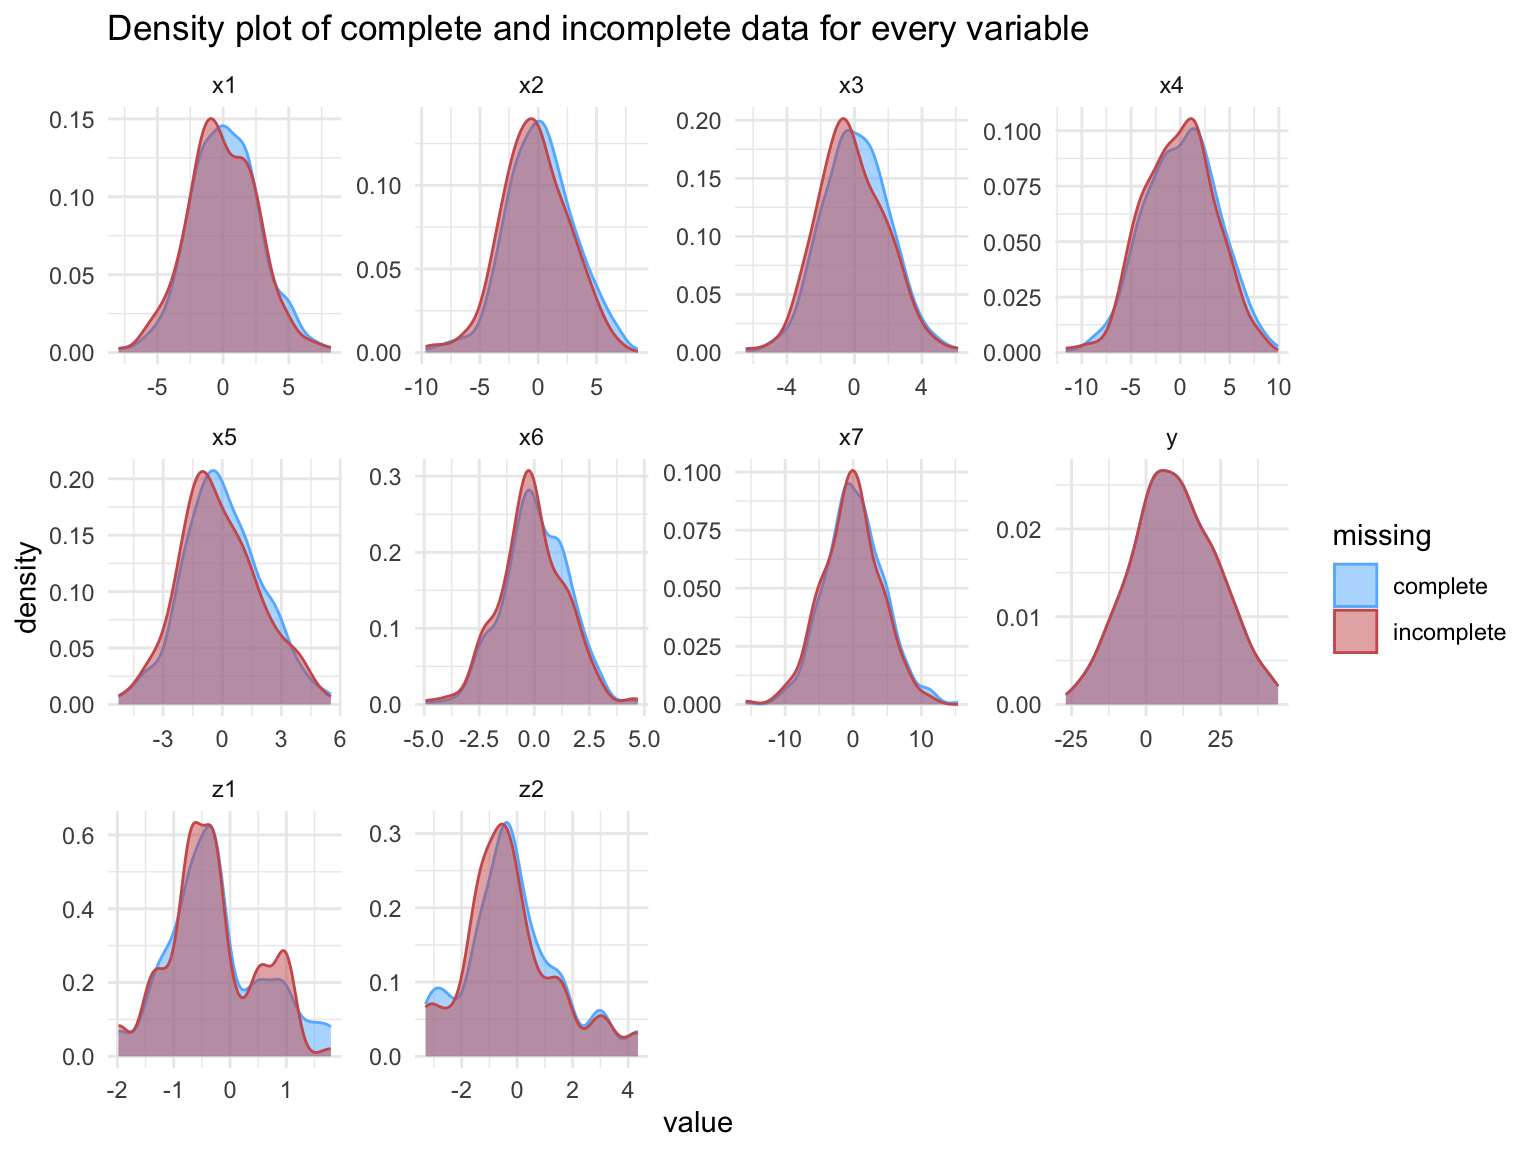

In [ ]:
dat <- cbind(data.relevant[[1]][[1]], missing[[1]][[1]]$data) %>%
    pivot_longer(cols = everything(), names_to = "data", values_to = "value") %>%
    mutate(missing = rep(c("complete", "incomplete"), each = ncol(data.relevant[[1]][[1]]), times = nrow(data.relevant[[1]][[1]])))

ggplot(dat, aes(x = value)) +
    geom_density(aes(fill = missing, color = missing), alpha = 0.5) +
    facet_wrap(~data, scales = "free") +
    scale_fill_manual(values = c("#63B8FF", "#CD5C5C")) +
    scale_color_manual(values = c("#63B8FF", "#CD5C5C")) +
    theme_minimal() +
    labs(title = "Density plot of complete and incomplete data for every variable")

## Creating missing data in a multivariate way

### No grouping

### Grouping

## Other articles